# Assignment 7: Customer Segmentation using K-Means Clustering and PCA

**Topic:** Customer Segmentation using K-Means Clustering and Principal Component Analysis (PCA)

**Dataset:** Mall Customer Segmentation Dataset
Kaggle Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**Problem Statement:** A shopping mall wants to divide its customers into different groups based on their annual income and spending behavior. The management plans to use these groups for targeted marketing campaigns. This notebook develops a K-Means Clustering model to segment customers and applies Principal Component Analysis (PCA) to visualize the clusters in two dimensions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42


## Task 1: Data Understanding (2 Marks)

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical and categorical features.
4. Display the dataset information and summary statistics.


In [2]:
# 1. Load the dataset
df = pd.read_csv("data/Mall_Customers.csv")
print("Dataset shape:", df.shape)


Dataset shape: (200, 5)


In [3]:
# 2. Display the first five records
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# 3. Identify numerical and categorical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features   :", numerical_features)
print("Categorical features :", categorical_features)


Numerical features   : ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features : ['Gender']


/tmp/ipykernel_607/3472243110.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


In [5]:
# 4. Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
# 4. Summary statistics
df.describe(include="all")


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## Task 2: Data Preprocessing (2 Marks)

- Check for missing values.
- Remove unnecessary columns (e.g., CustomerID).
- Encode categorical variables if required.
- Standardize the numerical features using StandardScaler.


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


In [8]:
# Remove unnecessary columns (CustomerID is just an identifier, not useful for clustering)
df_processed = df.drop(columns=["CustomerID"])
df_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [9]:
# Encode categorical variables (Gender: Male/Female -> 0/1)
le = LabelEncoder()
df_processed["Gender"] = le.fit_transform(df_processed["Gender"])  # Female=0, Male=1
df_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [10]:
# Standardize the numerical features using StandardScaler
features_for_clustering = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender"]
X = df_processed[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
X_scaled_df.head()


,Age,Annual Income (k$),Spending Score (1-100),Gender
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


## Task 3: Model Development (3 Marks)

1. Use the Elbow Method to determine the optimal number of clusters.
2. Train a K-Means Clustering model using the selected value of K.
3. Assign cluster labels to each customer.
4. Apply Principal Component Analysis (PCA) to reduce the dataset to 2 principal components.


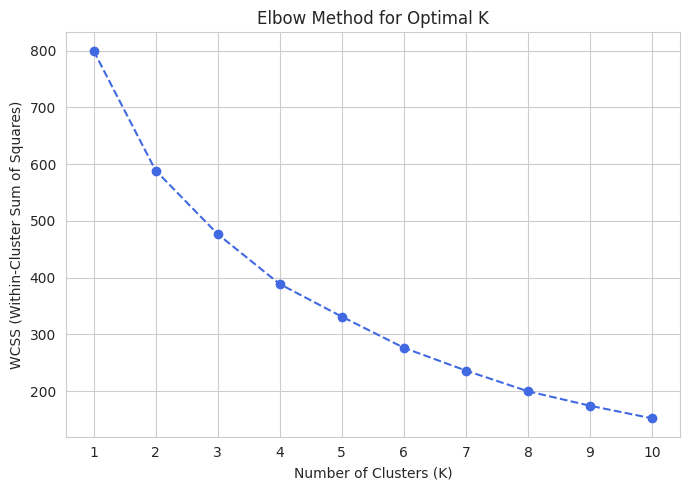

In [11]:
# 1. Elbow Method to determine optimal number of clusters
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), wcss, marker="o", linestyle="--", color="royalblue")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig("images/elbow_curve.png", dpi=150)
plt.show()


In [12]:
# 2. Train K-Means with the selected K (K=5 based on the elbow curve)
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 3. Assign cluster labels to each customer
df_processed["Cluster"] = cluster_labels
df.loc[:, "Cluster"] = cluster_labels
df_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


In [13]:
# 4. Apply PCA to reduce the dataset to 2 principal components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels

print("Explained variance ratio by each component:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))
pca_df.head()


Explained variance ratio by each component: [0.33690046 0.26230645]
Total variance explained by 2 components: 59.92%


,PC1,PC2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


## Task 4: Visualization and Evaluation (2 Marks)

- Elbow Curve (already generated above)
- Scatter plot showing customer clusters (Annual Income vs Spending Score)
- PCA visualization with cluster labels


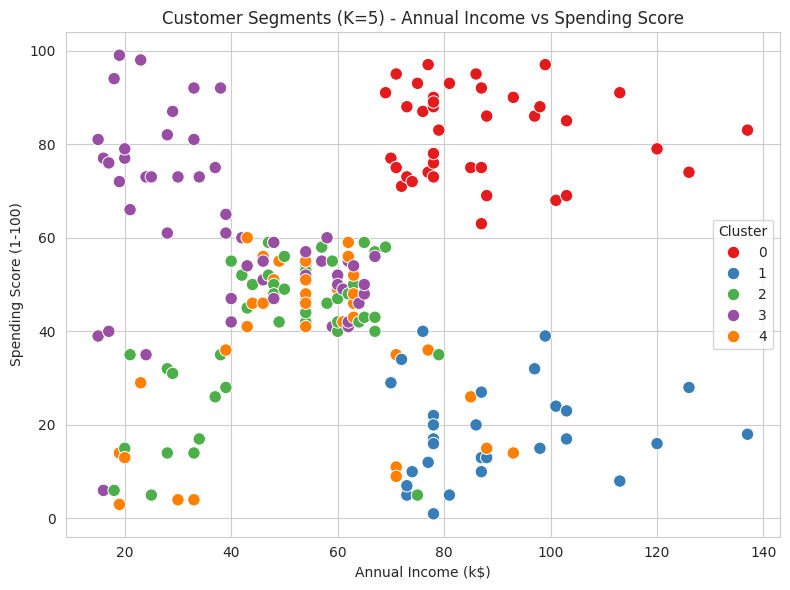

In [14]:
# Scatter plot showing customer clusters (using original business-relevant features)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_processed["Annual Income (k$)"],
    y=df_processed["Spending Score (1-100)"],
    hue=df_processed["Cluster"],
    palette="Set1",
    s=80
)
plt.title(f"Customer Segments (K={optimal_k}) - Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("images/cluster_scatter.png", dpi=150)
plt.show()


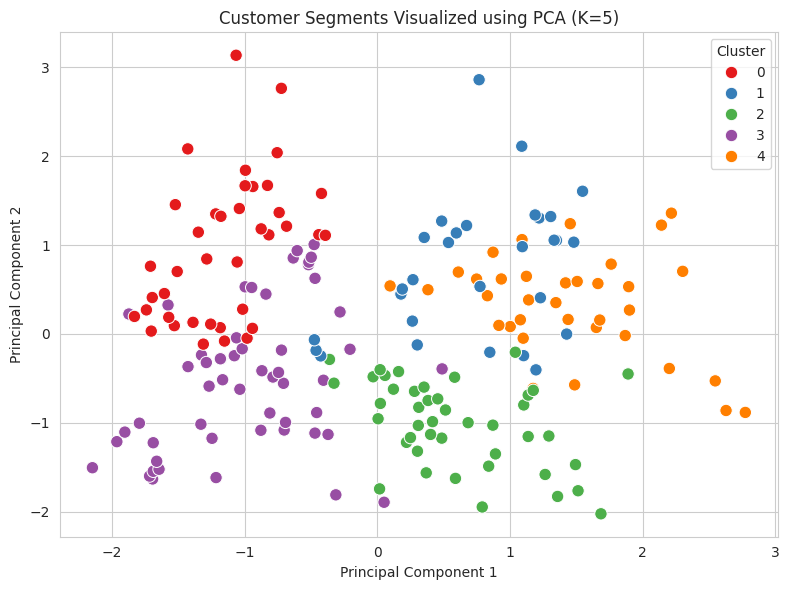

In [15]:
# PCA visualization with cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Cluster"],
    palette="Set1",
    s=80
)
plt.title(f"Customer Segments Visualized using PCA (K={optimal_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("images/pca_visualization.png", dpi=150)
plt.show()


In [16]:
# Cluster-wise summary statistics (helps write the observations below)
cluster_summary = df_processed.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Count"] = df_processed["Cluster"].value_counts().sort_index()
cluster_summary


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,32.7,86.5,82.1,39
1,36.5,89.5,18.0,29
2,49.8,49.2,40.1,43
3,24.9,39.7,61.2,54
4,55.7,53.7,36.8,35


### Observations

1. **Optimal number of clusters:** The Elbow Curve shows the WCSS decreasing sharply up to K=5, after which the decrease becomes much more gradual. This "elbow" at K=5 indicates that 5 clusters best balance model simplicity and within-cluster compactness for this dataset.
2. **How PCA helps visualize high-dimensional data:** The original dataset has 4 standardized features (Age, Annual Income, Spending Score, Gender), which cannot be plotted directly in a single 2D chart. PCA compresses these correlated features into 2 principal components that capture most of the variance in the data, allowing the customer clusters to be visualized on a single 2D scatter plot while still preserving the overall cluster structure.
3. **Characteristics of the identified customer groups:** The five clusters correspond to intuitive, distinct customer segments, for example: (a) high income & high spending score ("target/premium" customers), (b) high income & low spending score (cautious/careful spenders), (c) low income & high spending score (impulsive spenders), (d) low income & low spending score (budget-conscious customers), and (e) average income & average spending score (standard customers). The exact values for each cluster are shown in the `cluster_summary` table above.
4. **Consistency between the two visualizations:** The clusters formed on the raw Annual Income vs Spending Score plot closely match the groupings seen in the PCA-reduced 2D plot, confirming that PCA preserved the meaningful separation between customer segments even after dimensionality reduction.


## Task 5: Conclusion (1 Mark)

In this assignment, K-Means clustering was applied to the Mall Customer Segmentation dataset to group 200 customers into 5 distinct segments based on their age, annual income, spending score, and gender. The Elbow Method confirmed K=5 as the optimal number of clusters, and PCA was used to compress the standardized features into two principal components for clear 2D visualization, showing well-separated customer groups. These segments can help the mall's marketing team design targeted campaigns — for example, offering premium loyalty programs to high-income, high-spending customers, and discount-driven promotions to low-income, high-spending customers — improving marketing ROI and customer retention. A key limitation of K-Means is that it requires the number of clusters (K) to be specified in advance and assumes roughly spherical, similarly-sized clusters, which may not always reflect real customer behavior. An advantage of PCA is that it reduces dimensionality while retaining most of the data's variance, making complex, multi-feature data much easier to visualize and interpret without significant loss of information.
